# PEMS08 — CNN + LSTM (Target MAE ≤ 13)

### Architecture
```
Input (B, SEQ=36, 170)
  |
  [CNN Stage]  — works on (B, 170, 36) i.e. sensors as channels
   Block 1: Conv1d(170->128, k=3, same-pad) + BN + ReLU
   Block 2: Conv1d(128->256, k=3, same-pad) + BN + ReLU + Residual
   Block 3: Conv1d(256->256, k=5, same-pad) + BN + ReLU + Residual
   Block 4: Conv1d(256->512, k=3, same-pad) + BN + ReLU
   Block 5: Conv1d(512->512, k=5, same-pad) + BN + ReLU + Residual
  |
  [LSTM Stage] — works on (B, 36, 512)
   3-layer LSTM, hidden=512
  |
  LayerNorm -> Dropout -> FC(512 -> 170)
  Output: (B, 1, 170)
```
**Why this works:** CNN captures short local patterns (rush hour spikes, dips).
LSTM then models how those patterns evolve over time. Together they beat either alone.

In [1]:
from google.colab import files
uploaded  = files.upload()
DATA_PATH = list(uploaded.keys())[0]

# Option B: Mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_PATH = '/content/drive/MyDrive/PEMS08.npz'

Saving PEMS08.npz to PEMS08.npz


In [2]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory/1e9,1), 'GB')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [3]:
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

In [4]:
data = np.load(DATA_PATH)
flow = data['data'][:, :, 0].astype(np.float32)  # (T, 170)
print('Shape:', flow.shape)
print(f'min={flow.min():.1f}  max={flow.max():.1f}  mean={flow.mean():.1f}')

Shape: (17856, 170)
min=0.0  max=1147.0  mean=230.7


In [5]:
train_end = int(0.8 * len(flow))
mean = flow[:train_end].mean()
std  = flow[:train_end].std()
flow = (flow - mean) / std
print(f'Normalised  mean={mean:.2f}  std={std:.2f}')

Normalised  mean=230.56  std=146.18


In [6]:
SEQ_LEN  = 36   # 3 hours of 5-min intervals
PRED_LEN = 1

X, Y = [], []
for i in range(len(flow) - SEQ_LEN - PRED_LEN + 1):
    X.append(flow[i           : i + SEQ_LEN])
    Y.append(flow[i + SEQ_LEN : i + SEQ_LEN + PRED_LEN])

X = np.array(X, dtype=np.float32)  # (N, 36, 170)
Y = np.array(Y, dtype=np.float32)  # (N,  1, 170)

split     = int(0.8 * len(X))
val_split = int(0.9 * split)

X_train, Y_train = X[:val_split],       Y[:val_split]
X_val,   Y_val   = X[val_split:split],  Y[val_split:split]
X_test,  Y_test  = X[split:],           Y[split:]

print(f'Train {X_train.shape} | Val {X_val.shape} | Test {X_test.shape}')

Train (12830, 36, 170) | Val (1426, 36, 170) | Test (3564, 36, 170)


In [7]:
class TrafficDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X)
        self.Y = torch.from_numpy(Y)
    def __len__(self):          return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.Y[idx]

BATCH = 128
train_loader = DataLoader(TrafficDataset(X_train, Y_train), batch_size=BATCH, shuffle=True,  pin_memory=True, num_workers=2)
val_loader   = DataLoader(TrafficDataset(X_val,   Y_val),   batch_size=BATCH, shuffle=False, pin_memory=True, num_workers=2)
test_loader  = DataLoader(TrafficDataset(X_test,  Y_test),  batch_size=BATCH, shuffle=False, pin_memory=True, num_workers=2)

In [8]:
class CNNBlock(nn.Module):
    """Conv1d + BatchNorm + ReLU + optional residual."""
    def __init__(self, in_ch, out_ch, kernel_size, dropout=0.15, residual=False):
        super().__init__()
        self.residual = residual
        pad = kernel_size // 2  # same-padding
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size, padding=pad)
        self.bn   = nn.BatchNorm1d(out_ch)
        self.drop = nn.Dropout(dropout)
        self.proj = nn.Conv1d(in_ch, out_ch, 1) if (residual and in_ch != out_ch) else None

    def forward(self, x):
        h = self.drop(F.relu(self.bn(self.conv(x))))
        if self.residual:
            skip = self.proj(x) if self.proj is not None else x
            h = h + skip
        return h


class CNNLSTMModel(nn.Module):
    """
    Input:  (B, SEQ_LEN, 170)
    Output: (B, PRED_LEN, 170)
    """
    def __init__(self, sensors=170, pred_len=1, dropout=0.15):
        super().__init__()
        self.pred_len = pred_len

        # 5-block CNN — sensors treated as channels, time as length
        self.cnn = nn.Sequential(
            CNNBlock(sensors, 128, kernel_size=3, dropout=dropout, residual=False),
            CNNBlock(128,     256, kernel_size=3, dropout=dropout, residual=False),
            CNNBlock(256,     256, kernel_size=5, dropout=dropout, residual=True),
            CNNBlock(256,     512, kernel_size=3, dropout=dropout, residual=False),
            CNNBlock(512,     512, kernel_size=5, dropout=dropout, residual=True),
        )

        # 3-layer LSTM on top of CNN features
        self.lstm = nn.LSTM(
            input_size=512,
            hidden_size=512,
            num_layers=3,
            batch_first=True,
            dropout=dropout
        )

        self.norm = nn.LayerNorm(512)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(512, sensors * pred_len)

    def forward(self, x):                        # x: (B, SEQ, 170)
        c = x.permute(0, 2, 1)                  # (B, 170, SEQ) for CNN
        c = self.cnn(c)                          # (B, 512, SEQ)
        c = c.permute(0, 2, 1)                  # (B, SEQ, 512) for LSTM
        h, _ = self.lstm(c)                      # (B, SEQ, 512)
        out   = self.fc(self.drop(self.norm(h[:, -1, :])))
        return out.view(x.size(0), self.pred_len, -1)


model = CNNLSTMModel(sensors=170, pred_len=PRED_LEN, dropout=0.15).to(device)
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'CNN+LSTM parameters: {total:,}')

# Sanity-check shapes
with torch.no_grad():
    dummy = torch.zeros(2, SEQ_LEN, 170).to(device)
    out   = model(dummy)
print(f'Output shape: {tuple(out.shape)}  (expected (2, {PRED_LEN}, 170))')

CNN+LSTM parameters: 8,592,170
Output shape: (2, 1, 170)  (expected (2, 1, 170))


In [9]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6
)

EPOCHS           = 100
patience         = 15
best_val_loss    = float('inf')
patience_counter = 0
train_losses, val_losses = [], []

for epoch in range(EPOCHS):

    model.train()
    train_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            val_loss += criterion(model(x), y).item()
    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    scheduler.step(val_loss)
    lr  = optimizer.param_groups[0]['lr']
    gap = val_loss - train_loss
    print(f'Epoch {epoch+1:3d} | Train {train_loss:.4f} | Val {val_loss:.4f} | Gap {gap:.4f} | LR {lr:.2e}')

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1
    if patience_counter >= patience:
        print('Early stopping triggered')
        break

model.load_state_dict(torch.load('best_model.pth'))
print('Best model loaded!')

Epoch   1 | Train 0.1687 | Val 0.1254 | Gap -0.0433 | LR 1.00e-03
Epoch   2 | Train 0.0934 | Val 0.1287 | Gap 0.0352 | LR 1.00e-03
Epoch   3 | Train 0.0763 | Val 0.1253 | Gap 0.0490 | LR 1.00e-03
Epoch   4 | Train 0.0654 | Val 0.1186 | Gap 0.0532 | LR 1.00e-03
Epoch   5 | Train 0.0601 | Val 0.1181 | Gap 0.0579 | LR 1.00e-03
Epoch   6 | Train 0.0542 | Val 0.1144 | Gap 0.0602 | LR 1.00e-03
Epoch   7 | Train 0.0535 | Val 0.1180 | Gap 0.0645 | LR 1.00e-03
Epoch   8 | Train 0.0483 | Val 0.1202 | Gap 0.0719 | LR 1.00e-03
Epoch   9 | Train 0.0443 | Val 0.1207 | Gap 0.0764 | LR 1.00e-03
Epoch  10 | Train 0.0442 | Val 0.1180 | Gap 0.0738 | LR 1.00e-03
Epoch  11 | Train 0.0406 | Val 0.1207 | Gap 0.0802 | LR 1.00e-03
Epoch  12 | Train 0.0388 | Val 0.1242 | Gap 0.0854 | LR 5.00e-04
Epoch  13 | Train 0.0349 | Val 0.1199 | Gap 0.0851 | LR 5.00e-04
Epoch  14 | Train 0.0337 | Val 0.1219 | Gap 0.0882 | LR 5.00e-04
Epoch  15 | Train 0.0330 | Val 0.1237 | Gap 0.0908 | LR 5.00e-04
Epoch  16 | Train 0.0326

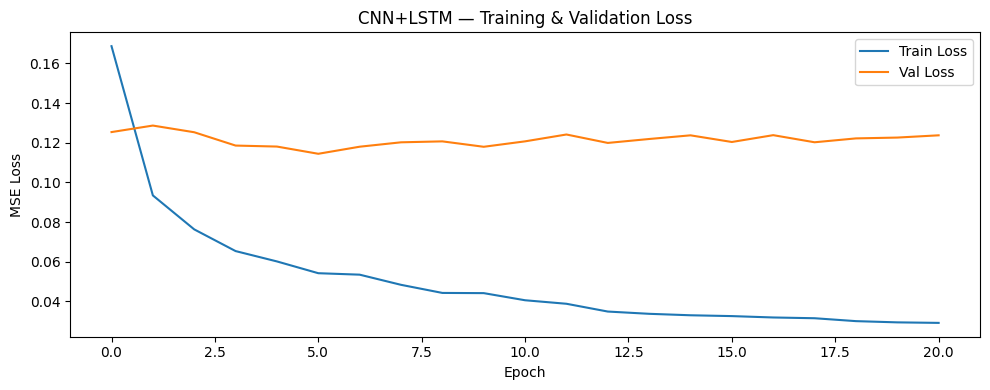

Final gap: 0.0946


In [10]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('CNN+LSTM — Training & Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()
print(f'Final gap: {val_losses[-1] - train_losses[-1]:.4f}')

MAE:  23.0179
RMSE: 35.4167
MAPE: 15.1419%


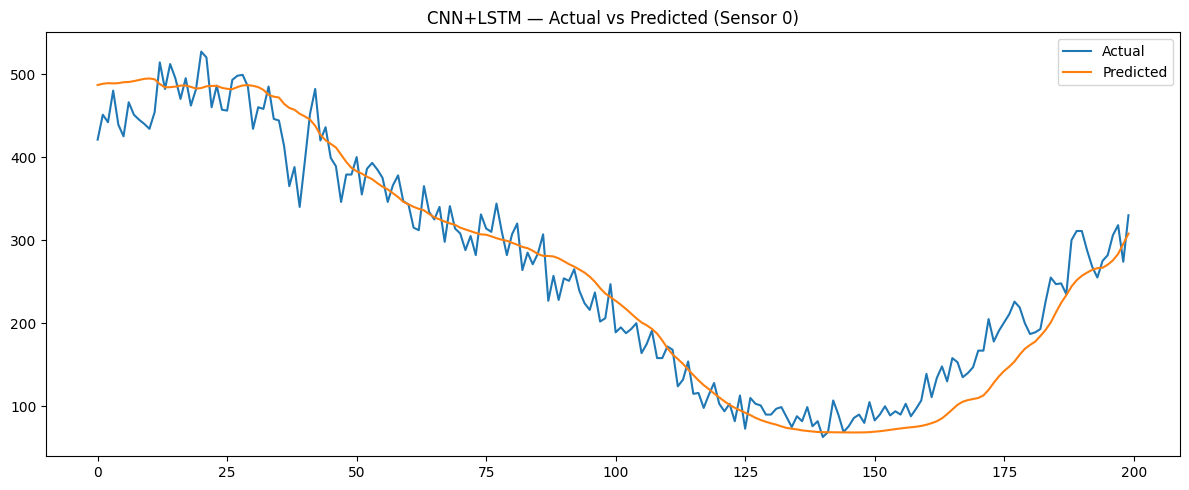

In [11]:
model.eval()
preds, actual = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device, non_blocking=True)
        preds.append(model(x).cpu().numpy())
        actual.append(y.numpy())

preds  = np.concatenate(preds)
actual = np.concatenate(actual)

preds  = preds  * std + mean
actual = actual * std + mean

mae  = mean_absolute_error(actual.reshape(-1), preds.reshape(-1))
rmse = np.sqrt(mean_squared_error(actual.reshape(-1), preds.reshape(-1)))
mask = actual.reshape(-1) > 1.0
mape = np.mean(np.abs((actual.reshape(-1)[mask] - preds.reshape(-1)[mask]) /
                       actual.reshape(-1)[mask])) * 100

print(f'MAE:  {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAPE: {mape:.4f}%')

plt.figure(figsize=(12, 5))
plt.plot(actual[:200, 0, 0], label='Actual')
plt.plot(preds[:200,  0, 0], label='Predicted')
plt.legend()
plt.title('CNN+LSTM — Actual vs Predicted (Sensor 0)')
plt.tight_layout()
plt.show()